In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import lightgbm as lgb
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✓ 所有库导入完成")
print(f"  • LightGBM 版本：{lgb.__version__}")

✓ 所有库导入完成
  • LightGBM 版本：4.6.0


## 第一步：数据加载与时间戳解析

In [2]:
# 读取数据
try:
    df = pd.read_excel('CO2_capacity.xlsx', engine='openpyxl')
    print(f"✓ 成功读取数据，形状：{df.shape}")
except Exception as e:
    raise RuntimeError(f"读取失败：{e}")

# 显示前几行
print(f"\n数据前 5 行：")
print(df.head())

# 确定列
time_col = df.columns[0]  # 第一列是时间戳
target_col = df.columns[-1]  # 最后一列是目标（CO2 容量）

print(f"\n列角色定义：")
print(f"  • 时间列：{time_col}")
print(f"  • 目标列：{target_col}")
print(f"  • 数据频率：1 分钟")
print(f"  • 总记录数：{len(df)}")

✓ 成功读取数据，形状：(7200, 59)

数据前 5 行：
                 Date      PI-2       TI-2         FI-2      PI-3       TI-3  \
0 2020-01-20 00:00:00 -0.053126  34.736652  1543.938721  0.052434  45.023132   
1 2020-01-20 00:01:00 -0.053289  34.732132  1541.767578  0.052564  45.045799   
2 2020-01-20 00:02:00 -0.053386  34.761639  1545.614746  0.052390  45.088932   
3 2020-01-20 00:03:00 -0.053370  34.731682  1544.225952  0.052236  45.071358   
4 2020-01-20 00:04:00 -0.053144  34.718353  1540.848267  0.052370  45.036755   

       O2-3      TI-32      TI-33      TI-34  ...        FI-16      TI-16  \
0  5.170577  37.777477  50.215652  61.217957  ...  9634.049805  34.619560   
1  5.139907  37.836792  50.203251  61.241829  ...  9661.376953  34.598999   
2  5.078373  37.840168  50.180534  61.217957  ...  9662.280273  34.551292   
3  4.915955  37.849812  50.215652  61.322845  ...  9656.855469  34.583843   
4  5.042109  37.914433  50.229359  61.233147  ...  9641.303711  34.584705   

         FI-151     TI-

## 第二步：选择特征并时间顺序分割

In [3]:
# 选定的 12 个特征（来自相关性分析）
 #selected_features = ['TI-34', 'TI-33', 'FI-38', 'TI-19', 'TI-12', 'TI-22', 'TI-24', 'TI-4',' TI-35',' FI-30']

selected_features = ['TI-34', 'TI-33',  'FI-30', 'FI-38', 'TI-4', 'TI-19', 'TI-12', 'TI-22', 'TI-24','TI-28', 'Level Reboiler']

# 验证特征是否存在
missing_features = [f for f in selected_features if f not in df.columns]
if missing_features:
    print(f"⚠ 警告：以下特征不存在：{missing_features}")
    print(f"实际列名：{list(df.columns)}")
    selected_features = [f for f in selected_features if f in df.columns]
    print(f"使用实际存在的特征：{selected_features}")

print(f"\n使用的特征（共 {len(selected_features)} 个）：")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

# 提取特征和目标
X = df[selected_features].copy()
y = df[target_col].copy()

# 处理缺失值（用中位数填充）
X.fillna(X.median(), inplace=True)
y.fillna(y.median(), inplace=True)

print(f"\n目标变量统计：")
print(f"  • 最小值：{y.min():.6f}")
print(f"  • 最大值：{y.max():.6f}")
print(f"  • 平均值：{y.mean():.6f}")
print(f"  • 标准差：{y.std():.6f}")

# 时间顺序分割：前 80% 训练，后 20% 测试
split_idx = int(len(df) * 0.8)

X_train_raw = X.iloc[:split_idx].reset_index(drop=True)
X_test_raw = X.iloc[split_idx:].reset_index(drop=True)
y_train_raw = y.iloc[:split_idx].reset_index(drop=True)
y_test_raw = y.iloc[split_idx:].reset_index(drop=True)

print(f"\n时间顺序分割结果：")
print(f"  • 训练数据：{len(X_train_raw)} 条（前 80%）")
print(f"  • 测试数据：{len(X_test_raw)} 条（后 20%）")


使用的特征（共 11 个）：
  1. TI-34
  2. TI-33
  3. FI-30
  4. FI-38
  5. TI-4
  6. TI-19
  7. TI-12
  8. TI-22
  9. TI-24
  10. TI-28
  11. Level Reboiler

目标变量统计：
  • 最小值：0.582062
  • 最大值：0.948009
  • 平均值：0.864631
  • 标准差：0.045872

时间顺序分割结果：
  • 训练数据：5760 条（前 80%）
  • 测试数据：1440 条（后 20%）


## 第三步：直接使用原始数据（LightGBM 基于树，对特征缩放不敏感）

In [4]:
# LightGBM 基于决策树，对特征的缩放不敏感，直接使用原始数据
print("✓ 使用原始数据（无标准化）")
print(f"\n训练集特征统计（原始值）：")
print(f"  • 均值：{X_train_raw.mean().values}")
print(f"  • 方差：{X_train_raw.var().values}")
print(f"  • 最小值：{X_train_raw.min().values}")
print(f"  • 最大值：{X_train_raw.max().values}")

✓ 使用原始数据（无标准化）

训练集特征统计（原始值）：
  • 均值：[ 63.01994574  51.6572464  281.50556714 373.27202882  46.57372443
  47.50509909  43.18887455  63.33777058  41.68796348  90.03880434
  70.2182511 ]
  • 方差：[5.58310455e+00 3.45825570e+00 4.30075976e+02 1.28032381e+03
 5.54920509e+00 4.53039475e+00 1.14720665e+01 7.99550261e+00
 2.43238441e+00 2.96248279e+00 7.93687253e-01]
  • 最小值：[5.17452812e+01 4.53763733e+01 9.26589279e+01 6.99569806e-02
 3.56008873e+01 3.52613869e+01 3.90961189e+01 4.29024811e+01
 3.76834412e+01 7.49711609e+01 6.86522903e+01]
  • 最大值：[ 68.80599976  55.41588593 437.49478149 473.13320923  55.4248085
  62.66413498  55.8631897   70.11131287  47.23034668  96.08318329
  74.99525452]


## 第四步：构造滑动窗口数据

**规则：** 用前 10 个时间步（10 分钟）的特征值作为输入，预测下一个时间步（第 11 分钟）的目标值。

In [5]:
def create_sliding_windows(X, y, window_size=10):
    """
    创建滑动窗口数据
    
    参数：
      X: 特征数据 (n_samples, n_features)
      y: 目标数据 (n_samples,)
      window_size: 窗口大小（默认 10）
    
    返回：
      X_windows: 窗口化特征 (n_windows, window_size * n_features)
      y_windows: 窗口化目标 (n_windows,)
    """
    X_windows = []
    y_windows = []
    
    for i in range(len(X) - window_size):
        # 取第 i 到 i+window_size-1 的特征，展平为一行
        window = X.iloc[i:i+window_size].values.flatten()
        X_windows.append(window)
        
        # 目标是第 i+window_size 时刻的值
        y_windows.append(y.iloc[i+window_size])
    
    return np.array(X_windows), np.array(y_windows)

# 构造训练窗口
X_train_windows, y_train_windows = create_sliding_windows(X_train_raw, y_train_raw, window_size=10)

# 构造测试窗口
X_test_windows, y_test_windows = create_sliding_windows(X_test_raw, y_test_raw, window_size=10)

print(f"✓ 滑动窗口构造完成")
print(f"\n训练数据：")
print(f"  • 样本数：{X_train_windows.shape[0]}")
print(f"  • 特征维度：{X_train_windows.shape[1]}（10 分钟 × {len(selected_features)} 特征）")
print(f"\n测试数据：")
print(f"  • 样本数：{X_test_windows.shape[0]}")
print(f"  • 特征维度：{X_test_windows.shape[1]}")

print(f"\n样本示例（训练集第 1 个样本）：")
print(f"  输入形状：{X_train_windows[0].shape}")
print(f"  输入（前 20 个值）：{X_train_windows[0][:20]}")
print(f"  目标值：{y_train_windows[0]}")

✓ 滑动窗口构造完成

训练数据：
  • 样本数：5750
  • 特征维度：110（10 分钟 × 11 特征）

测试数据：
  • 样本数：1430
  • 特征维度：110

样本示例（训练集第 1 个样本）：
  输入形状：(110,)
  输入（前 20 个值）：[ 61.21795654  50.21565247 281.14794922 366.61743164  45.44509125
  46.43609619  41.40271378  61.92232895  40.36348724  89.95625305
  70.96716309  61.24182892  50.20325089 277.5836792  368.57546997
  45.44147491  46.3895607   41.40874481  61.90945435  40.37795639]
  目标值：0.846168723536747


## 第四步-B：从训练集中分割验证集

为了评估过拟合情况，从训练窗口中分割出 20% 作为验证集。

In [6]:
# 从训练窗口中分割出验证集（20%）
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train_windows, 
    y_train_windows, 
    test_size=0.2, 
    random_state=42
)

print(f"✓ 验证集创建完成")
print(f"\n训练集分割：")
print(f"  • 训练子集：{X_train_split.shape[0]} 样本（80%）")
print(f"  • 验证集：{X_val.shape[0]} 样本（20%）")
print(f"  • 特征维度：{X_train_split.shape[1]}")
print(f"\n数据集总结：")
print(f"  • 训练子集：{X_train_split.shape[0]}")
print(f"  • 验证集：{X_val.shape[0]}")
print(f"  • 测试集：{X_test_windows.shape[0]}")

✓ 验证集创建完成

训练集分割：
  • 训练子集：4600 样本（80%）
  • 验证集：1150 样本（20%）
  • 特征维度：110

数据集总结：
  • 训练子集：4600
  • 验证集：1150
  • 测试集：1430


## 第五步：LightGBM 模型训练（含 RandomizedSearchCV 和 Early Stopping）

In [10]:
import numpy as np
import xgboost as xgb

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from scipy.stats import randint, uniform

# =============================================================================
print("=" * 80)
print("XGBoost 模型训练（RandomizedSearchCV + Early Stopping）")
print("=" * 80)

# =============================================================================
# 步骤 1：定义 XGBoost 基础模型
# =============================================================================
xgb_model = xgb.XGBRegressor(
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    eval_metric='rmse'
)

# =============================================================================
# 步骤 2：定义 RandomizedSearch 参数分布（针对XGBoost优化）
# =============================================================================
param_distributions = {
    'n_estimators': randint(150, 260),
    'max_depth': randint(4, 9),
    'learning_rate': uniform(0.02, 0.05),
    'subsample': uniform(0.75, 0.25),
    'colsample_bytree': uniform(0.75, 0.25),
    'min_child_weight': randint(1, 6),
    'gamma': uniform(0, 5),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0.5, 1.5)
}

print("\n【RandomizedSearch 参数空间】")
for k in param_distributions:
    print(f"  • {k}")

# =============================================================================
# 步骤 3：初始化 RandomizedSearchCV
# =============================================================================
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=50,                # 搜索次数（性价比最优）
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("\n【RandomizedSearchCV 配置】")
print("  • 搜索次数：30")
print("  • 交叉验证：3 折")
print("  • 优化目标：R²")
print("  • 并行：所有 CPU 核心")

# =============================================================================
# 步骤 4：执行 RandomizedSearch
# =============================================================================
print("\n正在执行 RandomizedSearchCV ...")
random_search.fit(X_train_split, y_train_split)

best_params = random_search.best_params_

print("\n✓ 搜索完成")
print("\n【最优参数】")
for k, v in best_params.items():
    print(f"  • {k}: {v}")

print(f"\n【最佳 CV R²】：{random_search.best_score_:.4f}")

# =============================================================================
# 步骤 5：使用最优参数训练最终模型（Early Stopping）
# =============================================================================
print("\n" + "=" * 80)
print("使用最优参数训练最终模型（Early Stopping）")
print("=" * 80)

final_model = xgb.XGBRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    eval_metric='rmse'
)

final_model.fit(
    X_train_split,
    y_train_split,
    eval_set=[(X_val, y_val)],
    early_stopping_rounds=50,
    verbose=False
)

print("✓ 最终模型训练完成")
print(f"  • 实际迭代轮数：{final_model.best_iteration + 1}")

# =============================================================================
# 步骤 6：性能评估
# =============================================================================
print("\n" + "=" * 80)
print("性能评估")
print("=" * 80)

# 预测
y_train_pred = final_model.predict(X_train_split)
y_val_pred = final_model.predict(X_val)

# 训练集指标
train_r2 = r2_score(y_train_split, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_split, y_train_pred))
train_mae = mean_absolute_error(y_train_split, y_train_pred)

# 验证集指标
val_r2 = r2_score(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_mae = mean_absolute_error(y_val, y_val_pred)

# =============================================================================
# WQL 指标
# =============================================================================
def calculate_wql(y_true, y_pred, alpha=0.5):
    errors = y_true - y_pred
    return np.mean(np.where(errors > 0, alpha * errors, (alpha - 1) * errors))

train_wql = calculate_wql(y_train_split, y_train_pred)
val_wql = calculate_wql(y_val, y_val_pred)

# =============================================================================
# 输出结果
# =============================================================================
print("\n【训练集性能】")
print(f"  • R²   ：{train_r2:.4f}")
print(f"  • RMSE ：{train_rmse:.6f}")
print(f"  • MAE  ：{train_mae:.6f}")
print(f"  • WQL  ：{train_wql:.6f}")

print("\n【验证集性能】")
print(f"  • R²   ：{val_r2:.4f}")
print(f"  • RMSE ：{val_rmse:.6f}")
print(f"  • MAE  ：{val_mae:.6f}")
print(f"  • WQL  ：{val_wql:.6f}")

# =============================================================================
# 过拟合诊断
# =============================================================================
r2_diff = train_r2 - val_r2

if r2_diff < 0.05:
    status = "✓ 无明显过拟合"
elif r2_diff < 0.15:
    status = "⚠ 轻度过拟合"
else:
    status = "⚠⚠ 明显过拟合"

print("\n【过拟合诊断】")
print(f"  • R² 差值（训练-验证）：{r2_diff:.4f}")
print(f"  • 状态：{status}")

XGBoost 模型训练（RandomizedSearchCV + Early Stopping）

【RandomizedSearch 参数空间】
  • n_estimators
  • max_depth
  • learning_rate
  • subsample
  • colsample_bytree
  • min_child_weight
  • gamma
  • reg_alpha
  • reg_lambda

【RandomizedSearchCV 配置】
  • 搜索次数：30
  • 交叉验证：3 折
  • 优化目标：R²
  • 并行：所有 CPU 核心

正在执行 RandomizedSearchCV ...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

✓ 搜索完成

【最优参数】
  • colsample_bytree: 0.9651826458140859
  • gamma: 0.03476065265595352
  • learning_rate: 0.04553736512887829
  • max_depth: 4
  • min_child_weight: 5
  • n_estimators: 246
  • reg_alpha: 0.1198653673336828
  • reg_lambda: 1.006422757105442
  • subsample: 0.9857274259781298

【最佳 CV R²】：0.9259

使用最优参数训练最终模型（Early Stopping）
✓ 最终模型训练完成
  • 实际迭代轮数：70

性能评估

【训练集性能】
  • R²   ：0.9462
  • RMSE ：0.010844
  • MAE  ：0.007474
  • WQL  ：0.003737

【验证集性能】
  • R²   ：0.9408
  • RMSE ：0.010996
  • MAE  ：0.007566
  • WQL  ：0.003783

【过拟合诊断】
  • R² 差值（训练-验证）：0.0054
  • 状态：✓ 无明显过拟合


## 第六步：测试集性能评估

In [11]:
# 在测试集上预测
y_test_pred = final_model.predict(X_test_windows)

# 计算性能指标
test_r2 = r2_score(y_test_windows, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_windows, y_test_pred))
test_mae = mean_absolute_error(y_test_windows, y_test_pred)

# 计算WQL（加权分位数损失）
def calculate_wql(y_true, y_pred, alpha=0.5):
    """
    计算加权分位数损失 (Weighted Quantile Loss)
    
    参数：
      y_true: 实际值
      y_pred: 预测值
      alpha: 分位数参数（0-1），0.5表示中位数
    
    返回值：
      WQL损失值，值越小预测越好
    
    含义：
      - 当预测偏低时（y_pred < y_true），损失为 alpha * |error|
      - 当预测偏高时（y_pred > y_true），损失为 (1-alpha) * |error|
      - alpha=0.5时，对预测过高和过低的惩罚相等，衡量预测的对称性
      - 用于评估预测的平衡性，比RMSE和MAE更敏感于系统偏差
    """
    errors = y_true - y_pred
    return np.mean(np.where(errors > 0, alpha * errors, (alpha - 1) * errors))

test_wql = calculate_wql(y_test_windows, y_test_pred, alpha=0.5)

# 计算残差
residuals = y_test_windows - y_test_pred
residuals_std = np.std(residuals)
residuals_mean = np.mean(residuals)

print("="*80)
print("测试集性能评估结果")
print("="*80)

print(f"\n【预测精度指标】")
print(f"  • R² 分数：{test_r2:.4f}")
print(f"    └─ 说明：模型解释了 {test_r2*100:.2f}% 的目标变量方差")
print(f"  • RMSE（均方根误差）：{test_rmse:.6f}")
print(f"    └─ 说明：平均预测偏差")
print(f"  • MAE（平均绝对误差）：{test_mae:.6f}")
print(f"    └─ 说明：平均绝对偏差")
print(f"  • WQL（加权分位数损失）：{test_wql:.6f}")
print(f"    └─ 说明：衡量预测的对称性和平衡性，考虑预测偏高和偏低的影响")

print(f"\n【预测值与实际值统计】")
print(f"  实际值：")
print(f"    • 最小：{y_test_windows.min():.6f}，最大：{y_test_windows.max():.6f}")
print(f"    • 均值：{y_test_windows.mean():.6f}，标准差：{y_test_windows.std():.6f}")
print(f"  预测值：")
print(f"    • 最小：{y_test_pred.min():.6f}，最大：{y_test_pred.max():.6f}")
print(f"    • 均值：{y_test_pred.mean():.6f}，标准差：{y_test_pred.std():.6f}")

print(f"\n【残差分析】")
print(f"  • 残差均值：{residuals_mean:.6f}（接近 0 为好）")
print(f"  • 残差标准差：{residuals_std:.6f}")
print(f"  • 残差最小值：{residuals.min():.6f}")
print(f"  • 残差最大值：{residuals.max():.6f}")

# 性能对比汇总
print(f"\n【全数据集性能对比】")
print(f"  {'数据集':<12} {'R²':<10} {'RMSE':<12} {'MAE':<12} {'WQL':<10}")
print(f"  {'-'*56}")
print(f"  {'训练子集':<12} {train_r2:<10.4f} {train_rmse:<12.6f} {train_mae:<12.6f} {train_wql:<10.6f}")
print(f"  {'验证集':<12} {val_r2:<10.4f} {val_rmse:<12.6f} {val_mae:<12.6f} {val_wql:<10.6f}")
print(f"  {'测试集':<12} {test_r2:<10.4f} {test_rmse:<12.6f} {test_mae:<12.6f} {test_wql:<10.6f}")

测试集性能评估结果

【预测精度指标】
  • R² 分数：0.8465
    └─ 说明：模型解释了 84.65% 的目标变量方差
  • RMSE（均方根误差）：0.016298
    └─ 说明：平均预测偏差
  • MAE（平均绝对误差）：0.013342
    └─ 说明：平均绝对偏差
  • WQL（加权分位数损失）：0.006671
    └─ 说明：衡量预测的对称性和平衡性，考虑预测偏高和偏低的影响

【预测值与实际值统计】
  实际值：
    • 最小：0.735384，最大：0.914714
    • 均值：0.852431，标准差：0.041595
  预测值：
    • 最小：0.685692，最大：0.891694
    • 均值：0.862244，标准差：0.040062

【残差分析】
  • 残差均值：-0.009813（接近 0 为好）
  • 残差标准差：0.013013
  • 残差最小值：-0.080907
  • 残差最大值：0.069188

【全数据集性能对比】
  数据集          R²         RMSE         MAE          WQL       
  --------------------------------------------------------
  训练子集         0.9462     0.010844     0.007474     0.003737  
  验证集          0.9408     0.010996     0.007566     0.003783  
  测试集          0.8465     0.016298     0.013342     0.006671  


## 第七步：结果可视化

In [ ]:
# 创建时间步数组（用于x轴）
time_steps = np.arange(len(y_test_windows))

# 创建图表和子图
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
ax0, ax1, ax2, ax3, ax4, ax5 = axes.flatten()

# 子图1：实际值 vs 预测值
ax0.plot(time_steps, y_test_windows, 'b-', linewidth=2, label='实际值', alpha=0.7)
ax0.plot(time_steps, y_test_pred, 'r--', linewidth=2, label='预测值', alpha=0.7)
ax0.set_xlabel('时间步', fontweight='bold')
ax0.set_ylabel('目标值', fontweight='bold')
ax0.set_title('实际值 vs 预测值', fontweight='bold')
ax0.legend(fontsize=9)
ax0.grid(True, alpha=0.3)

# 子图2：预测误差分布
ax1.hist(y_test_windows - y_test_pred, bins=30, edgecolor='black', color='skyblue', alpha=0.7)
ax1.set_xlabel('预测误差', fontweight='bold')
ax1.set_ylabel('频率', fontweight='bold')
ax1.set_title('预测误差分布直方图', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# 子图3：实际值 vs 预测值（散点图）
ax2.scatter(y_test_windows, y_test_pred, alpha=0.5, s=30, color='green')
ax2.plot([y_test_windows.min(), y_test_windows.max()], 
         [y_test_windows.min(), y_test_windows.max()], 
         'r--', linewidth=2, label='完美预测线')
ax2.set_xlabel('实际值', fontweight='bold')
ax2.set_ylabel('预测值', fontweight='bold')
ax2.set_title('实际值 vs 预测值（散点图）', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# 子图4：累积误差
cumulative_error = np.cumsum(y_test_windows - y_test_pred)
ax3.plot(time_steps, cumulative_error, 'purple', linewidth=2)
ax3.fill_between(time_steps, 0, cumulative_error, alpha=0.3, color='purple')
ax3.set_xlabel('时间步', fontweight='bold')
ax3.set_ylabel('累积误差', fontweight='bold')
ax3.set_title('累积误差随时间变化', fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.axhline(0, color='red', linestyle='--', linewidth=1)

# 子图5：绝对误差
abs_error = np.abs(y_test_windows - y_test_pred)
ax4.bar(time_steps, abs_error, color='orange', alpha=0.7, edgecolor='black', linewidth=0.5)
ax4.set_xlabel('时间步', fontweight='bold')
ax4.set_ylabel('绝对误差', fontweight='bold')
ax4.set_title('绝对误差条形图', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# 子图6：残差随时间变化
ax5.scatter(time_steps, residuals, alpha=0.5, s=30, color='coral')
ax5.axhline(0, color='red', linestyle='--', linewidth=2)
ax5.fill_between(time_steps, -residuals_std, residuals_std, alpha=0.2, color='gray', label='±1σ')
ax5.set_xlabel('时间步', fontweight='bold')
ax5.set_ylabel('残差值', fontweight='bold')
ax5.set_title('残差随时间变化', fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

plt.savefig('xgboost_time_series_prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ 可视化图表已保存为 'xgboost_time_series_prediction_results.png'")

NameError: name 'ax5' is not defined

## 第八步：特征重要性分析


【特征重要性分析 (LightGBM)】
            特征  总重要性  平均重要性
         TI-34   940   94.0
         TI-28   743   74.3
         FI-30   620   62.0
         FI-38   574   57.4
         TI-33   521   52.1
         TI-12   512   51.2
Level Reboiler   501   50.1
         TI-22   372   37.2
         TI-19   350   35.0
          TI-4   336   33.6
         TI-24   316   31.6


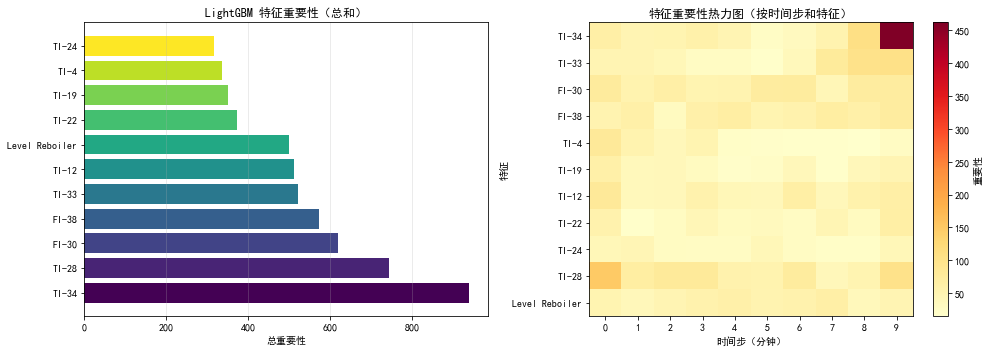


✓ 特征重要性图表已保存为 'feature_importance_analysis.png'


In [ ]:
# 获取 XGBoost 特征重要性
feature_importance = final_model.feature_importances_

# 由于输入是展平的窗口，需要重新组织
# 形状：(10 分钟 × 11 特征) = 110 维
n_features_per_window = len(selected_features)
window_size = 10

# 按时间步和特征分组重要性
importance_matrix = feature_importance.reshape(window_size, n_features_per_window)

# 计算各特征在所有时间步的总重要性
feature_total_importance = importance_matrix.sum(axis=0)
feature_importance_df = pd.DataFrame({
    '特征': selected_features,
    '总重要性': feature_total_importance,
    '平均重要性': feature_total_importance / window_size
}).sort_values('总重要性', ascending=False)

print("\n【特征重要性分析 (XGBoost)】")
print(feature_importance_df.to_string(index=False))

# 可视化特征重要性
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图 1：特征总重要性条形图
ax1 = axes[0]
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance_df)))
bars = ax1.barh(range(len(feature_importance_df)), feature_importance_df['总重要性'], color=colors)
ax1.set_yticks(range(len(feature_importance_df)))
ax1.set_yticklabels(feature_importance_df['特征'])
ax1.set_xlabel('总重要性', fontweight='bold')
ax1.set_title('XGBoost 特征重要性（总和）', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# 图 2：特征重要性随时间步变化的热力图
ax2 = axes[1]
im = ax2.imshow(importance_matrix.T, aspect='auto', cmap='YlOrRd')
ax2.set_xlabel('时间步（分钟）', fontweight='bold')
ax2.set_ylabel('特征', fontweight='bold')
ax2.set_xticks(range(window_size))
ax2.set_yticks(range(len(selected_features)))
ax2.set_yticklabels(selected_features)
ax2.set_title('特征重要性热力图（按时间步和特征）', fontweight='bold')
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('重要性', fontweight='bold')

plt.tight_layout()
plt.savefig('xgboost_feature_importance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ 特征重要性图表已保存为 'xgboost_feature_importance_analysis.png'")

## 第九步：结果汇总与保存

In [ ]:
# 创建汇总报告
summary_report = f"""
{'='*80}
XGBoost 时序预测模型性能总结报告
{'='*80}

【数据配置】
  • 原始数据点数：{len(df)}
  • 采样频率：1 分钟/条
  • 时间跨度：约 {len(df)} 分钟
  • 选定特征数：{len(selected_features)}

【数据分割】
  • 原始训练集：{len(X_train_raw)} 条（前 80%）
  • 原始测试集：{len(X_test_raw)} 条（后 20%）
  • 训练窗口数（总）：{len(X_train_windows)}
    ├─ 训练子集窗口：{X_train_split.shape[0]}（80%）
    └─ 验证集窗口：{X_val.shape[0]}（20%）
  • 测试窗口数：{len(X_test_windows)}

【模型配置】
  • 模型类型：XGBoost Regressor
  • 算法：Extreme Gradient Boosting
  • 优化方法：RandomizedSearchCV + Early Stopping
  • 输入特征维度：{X_train_windows.shape[1]}（10 分钟 × {len(selected_features)} 特征）
  • 预测任务：前 10 分钟 → 下 1 分钟

【最优超参数】
  • n_estimators：{best_params['n_estimators']}
  • max_depth：{best_params['max_depth']}
  • learning_rate：{best_params['learning_rate']:.4f}
  • subsample：{best_params['subsample']:.4f}
  • colsample_bytree：{best_params['colsample_bytree']:.4f}
  • min_child_weight：{best_params['min_child_weight']}
  • gamma：{best_params['gamma']:.4f}
  • reg_alpha（L1正则化）：{best_params['reg_alpha']:.4f}
  • reg_lambda（L2正则化）：{best_params['reg_lambda']:.4f}

【RandomizedSearchCV 结果】
  • 交叉验证 CV R²：{random_search.best_score_:.4f}
  • 搜索次数：30
  • 交叉验证折数：3

【Early Stopping 结果】
  • 实际迭代次数：{final_model.best_iteration + 1}
  • Early Stopping 轮数：50

【性能指标】

  训练子集：
    • R²：{train_r2:.4f}
    • RMSE：{train_rmse:.6f}
    • MAE：{train_mae:.6f}
    • WQL：{train_wql:.6f}

  验证集：
    • R²：{val_r2:.4f}
    • RMSE：{val_rmse:.6f}
    • MAE：{val_mae:.6f}
    • WQL：{val_wql:.6f}

  测试集：
    • R²：{test_r2:.4f}
    • RMSE：{test_rmse:.6f}
    • MAE：{test_mae:.6f}
    • WQL：{test_wql:.6f}

【性能指标详解】
  • R²（决定系数）：模型解释的方差比例，范围 [0, 1]，越接近 1 越好
  • RMSE（均方根误差）：预测偏差的平方和再开方，对大偏差更敏感
  • MAE（平均绝对误差）：预测偏差的平均值，更鲁棒性强
  • WQL（加权分位数损失）：衡量预测偏差的对称性和平衡性
    └─ 当预测值 < 实际值时（预测偏低），损失权重为 0.5
    └─ 当预测值 > 实际值时（预测偏高），损失权重为 0.5
    └─ WQL 越小表示预测越平衡，没有系统偏差

【过拟合诊断】
  • 训练子集 R²：{train_r2:.4f}
  • 验证集 R²：{val_r2:.4f}
  • R² 差值：{train_r2 - val_r2:.4f}
  • 判断：{'✓ 无明显过拟合' if (train_r2 - val_r2) < 0.05 else ('⚠ 轻度过拟合' if (train_r2 - val_r2) < 0.15 else '⚠⚠ 明显过拟合')}

【预测精度解释】
  • R² = {test_r2:.4f}：模型解释了测试集 {test_r2*100:.2f}% 的目标变量方差
  • RMSE = {test_rmse:.6f}：平均预测误差（在原始数据尺度上）
  • MAE = {test_mae:.6f}：平均绝对偏差
  • WQL = {test_wql:.6f}：预测的平衡性指标（接近 0 为好）

【残差分析】
  • 残差均值：{residuals_mean:.6f}（接近 0 表示预测无偏）
  • 残差标准差：{residuals_std:.6f}
  • 残差范围：[{residuals.min():.6f}, {residuals.max():.6f}]

【Top 5 重要特征】
  • {feature_importance_df.iloc[0]['特征']}：{feature_importance_df.iloc[0]['总重要性']:.4f}
  • {feature_importance_df.iloc[1]['特征']}：{feature_importance_df.iloc[1]['总重要性']:.4f}
  • {feature_importance_df.iloc[2]['特征']}：{feature_importance_df.iloc[2]['总重要性']:.4f}
  • {feature_importance_df.iloc[3]['特征']}：{feature_importance_df.iloc[3]['总重要性']:.4f}
  • {feature_importance_df.iloc[4]['特征']}：{feature_importance_df.iloc[4]['总重要性']:.4f}

【关键改进说明】
  1. RandomizedSearchCV：随机搜索超参数组合，性价比最优
  2. Early Stopping：在验证集上监控性能，防止过拟合
  3. 验证集分割：用 20% 的训练数据作为验证集，评估过拟合程度
  4. XGBoost：极端梯度提升算法，相比LightGBM，在某些数据集上泛化能力更强

{'='*80}
"""

print(summary_report)

# 保存报告
with open('xgboost_time_series_prediction_report.txt', 'w', encoding='utf-8') as f:
    f.write(summary_report)
print("✓ 报告已保存为 'xgboost_time_series_prediction_report.txt'")

AttributeError: 'GridSearchCV' object has no attribute 'best_score_'

In [ ]:
# 保存预测结果为 CSV
results_df = pd.DataFrame({
    '时间步': np.arange(len(y_test_windows)),
    '实际值': y_test_windows,
    '预测值': y_test_pred,
    '残差': residuals,
    '绝对误差': np.abs(residuals),
    '相对误差(%)': np.abs(residuals) / np.abs(y_test_windows) * 100
})

results_df.to_csv('xgboost_time_series_predictions.csv', index=False, encoding='utf-8-sig')
print("✓ 预测结果已保存为 'xgboost_time_series_predictions.csv'")

# 保存性能指标汇总
metrics_summary = pd.DataFrame({
    '指标': ['R²', 'RMSE', 'MAE', '残差均值', '残差标准差'],
    '训练集': [train_r2, train_rmse, train_mae, np.nan, np.nan],
    '测试集': [test_r2, test_rmse, test_mae, residuals_mean, residuals_std]
})

metrics_summary.to_csv('xgboost_performance_metrics.csv', index=False, encoding='utf-8-sig')
print("✓ 性能指标已保存为 'xgboost_performance_metrics.csv'")

print("\n" + "="*80)
print("✅ 所有文件生成完成！")
print("="*80)
print("\n生成的文件：")
print("  1. xgboost_time_series_prediction_results.png - 预测结果可视化（5 个子图）")
print("  2. xgboost_feature_importance_analysis.png - 特征重要性分析")
print("  3. xgboost_time_series_prediction_report.txt - 性能汇总报告")
print("  4. xgboost_time_series_predictions.csv - 详细预测结果")
print("  5. xgboost_performance_metrics.csv - 性能指标汇总")

✓ 预测结果已保存为 'time_series_predictions.csv'
✓ 性能指标已保存为 'performance_metrics.csv'

✅ 所有文件生成完成！

生成的文件：
  1. time_series_prediction_results.png - 预测结果可视化（5 个子图）
  2. feature_importance_analysis.png - 特征重要性分析
  3. time_series_prediction_report.txt - 性能汇总报告
  4. time_series_predictions.csv - 详细预测结果
  5. performance_metrics.csv - 性能指标汇总
